# Personal finance tracker and analyzer

The idea is simple:
- if `transactions.csv` or `transactions.json` is in the same folder, it reads it
- if `receipt.png` or `receipt.jpg` is in the same folder, it can read it with OCR
- if there is no file, you can type transactions by hand in one settings cell
- manual input format: `2026-03-19, 450, Cafe, coffee before class`


## Step 1. Imports And Setup

Here we import the libraries we need for the project.

In [26]:
from pathlib import Path
from datetime import datetime
import csv
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import requests
from IPython.display import display, Image as NotebookImage

# keep the output readable
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)

## Step 2. Transaction Class

Here we create the class for one expense row.

In [27]:
class Transaction:
    def __init__(self, date, amount, category, description):
        # check values before saving them
        self.date = self.validate_date(date)
        self.amount = self.validate_amount(amount)
        self.category = str(category).strip().title()
        self.description = str(description).strip()

        # text fields should not be empty
        if not self.category:
            raise ValueError('category cannot be empty')
        if not self.description:
            raise ValueError('description cannot be empty')

    @staticmethod
    def validate_date(date_text):
        # keep one date format everywhere
        try:
            datetime.strptime(str(date_text), '%Y-%m-%d')
            return str(date_text)
        except ValueError:
            raise ValueError('date must be in YYYY-MM-DD format')

    @staticmethod
    def validate_amount(amount_value):
        # convert text or int to float
        try:
            amount = float(amount_value)
        except ValueError:
            raise ValueError('amount must be a number')

        if amount <= 0:
            raise ValueError('amount must be greater than 0')
        return round(amount, 2)

    def to_dict(self):
        # this is useful for tables and saving
        return {
            'date': self.date,
            'amount': self.amount,
            'category': self.category,
            'description': self.description,
        }

## Step 3. FinanceManager Class

Here we create the class that stores and analyzes all transactions.

In [28]:
class FinanceManager:
    def __init__(self):
        # keep all transactions in one list
        self.transactions = []
        self.category_budgets = {}

    def add_transaction(self, transaction):
        # add one ready object
        self.transactions.append(transaction)

    def add_from_values(self, date, amount, category, description):
        # create and add in one step
        transaction = Transaction(date, amount, category, description)
        self.add_transaction(transaction)

    def delete_transaction(self, index):
        # remove one row by its id
        if index < 0 or index >= len(self.transactions):
            raise IndexError('transaction index is out of range')
        return self.transactions.pop(index)

    def to_dataframe(self):
        # turn the list into a pandas table
        rows = []
        for transaction in self.transactions:
            rows.append(transaction.to_dict())

        df = pd.DataFrame(rows)
        if not df.empty:
            df['date'] = pd.to_datetime(df['date'])
            df = df.sort_values('date').reset_index(drop=True)
        return df

    def load_from_csv(self, file_path):
        # read rows from csv
        self.transactions = []
        with open(file_path, 'r', encoding='utf-8') as file:
            reader = csv.DictReader(file)
            for row in reader:
                self.add_from_values(row['date'], row['amount'], row['category'], row['description'])

    def load_from_json(self, file_path):
        # read rows from json
        self.transactions = []
        with open(file_path, 'r', encoding='utf-8') as file:
            rows = json.load(file)
        for row in rows:
            self.add_from_values(row['date'], row['amount'], row['category'], row['description'])

    def main_stats(self, df=None):
        # calculate the main numbers
        if df is None:
            df = self.to_dataframe()

        if df.empty:
            return {}

        amounts = df['amount'].to_numpy()
        return {
            'count': len(amounts),
            'total_expense': round(float(np.sum(amounts)), 2),
            'average_expense': round(float(np.mean(amounts)), 2),
            'min_expense': round(float(np.min(amounts)), 2),
            'max_expense': round(float(np.max(amounts)), 2),
        }

    def category_breakdown(self, df=None):
        # sum money by category + percent of total
        if df is None:
            df = self.to_dataframe()

        if df.empty:
            return pd.DataFrame()

        grouped = df.groupby('category', as_index=False)['amount'].sum()
        grouped = grouped.sort_values('amount', ascending=False).reset_index(drop=True)

        total_amount = grouped['amount'].sum()
        if total_amount > 0:
            grouped['percent_of_total'] = (grouped['amount'] / total_amount * 100).round(2)
        else:
            grouped['percent_of_total'] = 0.0

        grouped['amount'] = grouped['amount'].round(2)
        return grouped

    def daily_trend(self, df=None):
        # sum money by day
        if df is None:
            df = self.to_dataframe()

        if df.empty:
            return pd.DataFrame()

        grouped = df.groupby('date', as_index=False)['amount'].sum()
        grouped['amount'] = grouped['amount'].round(2)
        return grouped

    def weekly_summary(self, df=None):
        # sum money by week
        if df is None:
            df = self.to_dataframe()

        if df.empty:
            return pd.DataFrame()

        df = df.copy()
        df['week_start'] = df['date'] - pd.to_timedelta(df['date'].dt.weekday, unit='D')
        df['week_start'] = df['week_start'].dt.normalize()

        grouped = df.groupby('week_start', as_index=False)['amount'].sum()
        grouped = grouped.sort_values('week_start').reset_index(drop=True)
        grouped['amount'] = grouped['amount'].round(2)
        return grouped

    def monthly_summary(self, df=None):
        # sum money by month
        if df is None:
            df = self.to_dataframe()

        if df.empty:
            return pd.DataFrame()

        df = df.copy()
        df['month'] = df['date'].dt.to_period('M').astype(str)

        grouped = df.groupby('month', as_index=False)['amount'].sum()
        grouped = grouped.sort_values('month').reset_index(drop=True)
        grouped['amount'] = grouped['amount'].round(2)
        return grouped

    def filter_transactions(self, category=None, start_date=None, end_date=None):
        # filter data by category and/or date range
        df = self.to_dataframe()

        if df.empty:
            return df

        filtered_df = df.copy()

        if category:
            category = str(category).strip().title()
            filtered_df = filtered_df[filtered_df['category'] == category]

        if start_date:
            start_date = pd.to_datetime(start_date)
            filtered_df = filtered_df[filtered_df['date'] >= start_date]

        if end_date:
            end_date = pd.to_datetime(end_date)
            filtered_df = filtered_df[filtered_df['date'] <= end_date]

        return filtered_df.reset_index(drop=True)

    def set_category_budget(self, category, amount):
        # save budget for one category
        category = str(category).strip().title()
        amount = float(amount)

        if amount <= 0:
            raise ValueError('budget must be greater than 0')

        self.category_budgets[category] = round(amount, 2)

    def set_category_budgets(self, budgets_dict):
        # save budgets from dictionary
        self.category_budgets = {}
        for category, amount in budgets_dict.items():
            self.set_category_budget(category, amount)

    def budget_report(self, df=None):
        # compare spending with category budgets
        if df is None:
            df = self.to_dataframe()

        if df.empty or not self.category_budgets:
            return pd.DataFrame()

        spent_df = self.category_breakdown(df)[['category', 'amount']].copy()

        budget_rows = []
        for category, budget in self.category_budgets.items():
            spent_value = 0.0
            matched = spent_df[spent_df['category'] == category]
            if not matched.empty:
                spent_value = float(matched.iloc[0]['amount'])

            remaining = round(budget - spent_value, 2)

            if spent_value > budget:
                status = 'Over budget'
            elif spent_value == budget:
                status = 'Limit reached'
            else:
                status = 'Within budget'

            budget_rows.append({
                'category': category,
                'budget': round(budget, 2),
                'spent': round(spent_value, 2),
                'remaining': remaining,
                'status': status,
            })

        return pd.DataFrame(budget_rows)

## Step 4. Settings

Here you can change the input options before running the notebook.

In [29]:
# use a file if it exists
LOAD_EXISTING_DATA = True
INPUT_DATA_FILE = ''   # leave empty to try transactions.csv or transactions.json

# type extra rows here if you want
# one line = one transaction
MANUAL_TRANSACTIONS = ''''''

# type ids here if you want to delete rows after loading
# example: '0, 2, 5'
DELETE_TRANSACTION_IDS = ''

# OCR settings
USE_RECEIPT_OCR = True
RECEIPT_FILE = ''   # leave empty to try receipt.png / receipt.jpg / check.png
RECEIPT_DATE = datetime.today().strftime('%Y-%m-%d')
OCR_API_KEY = 'K89851889288957'
OCR_LANGUAGE = 'auto'

# filters for analysis
FILTER_CATEGORY = ''          # example: 'Food'
FILTER_START_DATE = ''        # example: '2025-01-01'
FILTER_END_DATE = ''          # example: '2025-12-31'

# budgets by category
CATEGORY_BUDGETS = {
    'Groceries': 15000,
    'Shopping': 5000,
    'Cafe': 2000,
    'Entertainment': 2000}

## Step 5. Helper Functions

Here we keep the small helper functions for loading and input.

In [30]:
def find_transaction_file(preferred_name=''):
    # use the file name from settings if it exists
    if preferred_name:
        path = Path(preferred_name)
        if path.exists():
            return path

    # otherwise try the usual names
    for name in ['transactions.csv', 'transactions.json']:
        path = Path(name)
        if path.exists():
            return path

    return None



def find_receipt_file(preferred_name=''):
    # use the file name from settings if it exists
    if preferred_name:
        path = Path(preferred_name)
        if path.exists():
            return path

    # otherwise try the usual image names
    for name in [
        'receipt.png', 'receipt.jpg', 'receipt.jpeg', 'receipt.webp',
        'check.png', 'check.jpg', 'check.jpeg', 'check.webp',
    ]:
        path = Path(name)
        if path.exists():
            return path

    return None



def parse_manual_transactions(text):
    # read the lines typed by hand
    rows = []
    cleaned_text = text.strip()

    if not cleaned_text:
        return rows

    for line_number, line in enumerate(cleaned_text.splitlines(), start=1):
        if not line.strip():
            continue

        parts = [part.strip() for part in line.split(',', 3)]
        if len(parts) != 4:
            raise ValueError(f'manual row {line_number} must have 4 parts')

        rows.append(parts)

    return rows



def parse_delete_ids(text):
    # read ids that should be deleted
    if not text.strip():
        return []

    ids = []
    for part in text.split(','):
        part = part.strip()
        if part:
            ids.append(int(part))
    return sorted(set(ids), reverse=True)

## Step 6. Load Data

Here we load the file if it exists and then add manual rows.

In [31]:
manager = FinanceManager()
loaded_file = None

# load existing data if the option is on
if LOAD_EXISTING_DATA:
    loaded_file = find_transaction_file(INPUT_DATA_FILE)
    if loaded_file is not None:
        if loaded_file.suffix == '.csv':
            manager.load_from_csv(loaded_file)
        else:
            manager.load_from_json(loaded_file)
        print('loaded data from:', loaded_file.name)
    else:
        print('no transaction file was found')
else:
    print('loading from file is turned off')

# add manual rows after loading
manual_rows = parse_manual_transactions(MANUAL_TRANSACTIONS)
for date, amount, category, description in manual_rows:
    manager.add_from_values(date, amount, category, description)

if manual_rows:
    print('added manual rows:', len(manual_rows))

current_df = manager.to_dataframe()
if current_df.empty:
    print('there are no transactions yet')
else:
    print('current transactions before delete step')
    display(current_df.reset_index().rename(columns={'index': 'id'}))

loaded data from: transactions.csv
current transactions before delete step


,id,date,amount,category,description
0,0,2026-02-20,420.0,Groceries,small supermarket run
1,1,2026-02-20,165.0,Transport,metro top up
2,2,2026-02-21,320.0,Cafe,coffee and cake
3,3,2026-02-21,890.0,Groceries,vegetables and chicken
4,4,2026-02-22,760.0,Entertainment,movie and popcorn
...,...,...,...,...,...
49,49,2026-03-16,640.0,Health,pharmacy refill
50,50,2026-03-17,560.0,Cafe,dinner with friends
51,51,2026-03-17,215.0,Transport,taxi home
52,52,2026-03-18,1010.0,Groceries,supermarket run


## Step 7. Delete Rows

Here we delete transaction ids if you typed any in the settings.

In [32]:
delete_ids = parse_delete_ids(DELETE_TRANSACTION_IDS)
deleted_rows = []

for row_id in delete_ids:
    deleted_rows.append(manager.delete_transaction(row_id).to_dict())

if deleted_rows:
    print('deleted rows')
    display(pd.DataFrame(deleted_rows))
else:
    print('no rows were deleted')

current_df = manager.to_dataframe()
if current_df.empty:
    print('there are still no transactions')
else:
    print('transactions after delete step')
    display(current_df.reset_index().rename(columns={'index': 'id'}))

no rows were deleted
transactions after delete step


,id,date,amount,category,description
0,0,2026-02-20,420.0,Groceries,small supermarket run
1,1,2026-02-20,165.0,Transport,metro top up
2,2,2026-02-21,320.0,Cafe,coffee and cake
3,3,2026-02-21,890.0,Groceries,vegetables and chicken
4,4,2026-02-22,760.0,Entertainment,movie and popcorn
...,...,...,...,...,...
49,49,2026-03-16,640.0,Health,pharmacy refill
50,50,2026-03-17,560.0,Cafe,dinner with friends
51,51,2026-03-17,215.0,Transport,taxi home
52,52,2026-03-18,1010.0,Groceries,supermarket run


## Step 8. OCR Request Function

Here we send the receipt image to OCR.Space.

In [33]:
def call_ocr_space(image_path, api_key, language='auto'):
    # send the image to OCR.Space
    with open(image_path, 'rb') as image_file:
        response = requests.post(
            'https://api.ocr.space/parse/image',
            headers={'apikey': api_key},
            data={
                'language': language,
                'isOverlayRequired': True,
                'OCREngine': 2,
            },
            files={'file': image_file},
            timeout=30,
        )

    response.raise_for_status()
    result = response.json()

    if result.get('IsErroredOnProcessing'):
        message = result.get('ErrorMessage', ['ocr error'])
        raise ValueError(message[0])

    return result

## Step 9. OCR Parser

Here we turn the OCR response into product rows and prices.

In [34]:
def extract_price(text):
    # find values like 2.40 or 15.99
    cleaned = text.replace(' ', '').replace(',', '.')
    match = re.search(r'\d+\.\d{2}', cleaned)
    if match:
        return float(match.group())
    return None



def parse_receipt_items(ocr_result):
    # split lines into names and prices
    parsed = ocr_result['ParsedResults'][0]
    overlay_lines = parsed.get('TextOverlay', {}).get('Lines', [])

    left_lines = []
    price_lines = []
    ignore_words = {'total', 'subtotal', 'tax'}

    for line in overlay_lines:
        words = line.get('Words', [])
        if not words:
            continue

        text = line.get('LineText', '').strip()
        if not text:
            continue

        left = min(word['Left'] for word in words)
        top = line.get('MinTop', min(word['Top'] for word in words))
        lower_text = text.lower()

        if lower_text in ignore_words:
            continue
        if re.fullmatch(r'\d{4}-\d{2}-\d{2}', text):
            continue

        price = extract_price(text)
        if price is not None and left > 300:
            price_lines.append({'top': top, 'price': price})
        elif left < 300 and not re.search(r'\d', text):
            left_lines.append({'top': top, 'description': lower_text})

    items = []
    used_price_indexes = set()

    for left_line in left_lines:
        best_index = None
        best_gap = None

        for index, price_line in enumerate(price_lines):
            if index in used_price_indexes:
                continue

            gap = abs(price_line['top'] - left_line['top'])
            if gap <= 30 and (best_gap is None or gap < best_gap):
                best_gap = gap
                best_index = index

        if best_index is not None:
            used_price_indexes.add(best_index)
            items.append({
                'description': left_line['description'],
                'amount': price_lines[best_index]['price'],
                'category': 'Groceries',
            })

    return pd.DataFrame(items)



def add_receipt_items_to_manager(manager_object, receipt_items_df, receipt_date):
    # add OCR rows as normal transactions
    for _, row in receipt_items_df.iterrows():
        manager_object.add_from_values(
            receipt_date,
            row['amount'],
            row['category'],
            row['description'],
        )

## Step 10. Read Receipt

Here we try to read the receipt image, but if OCR fails the notebook continues.

using receipt file: receipt.png


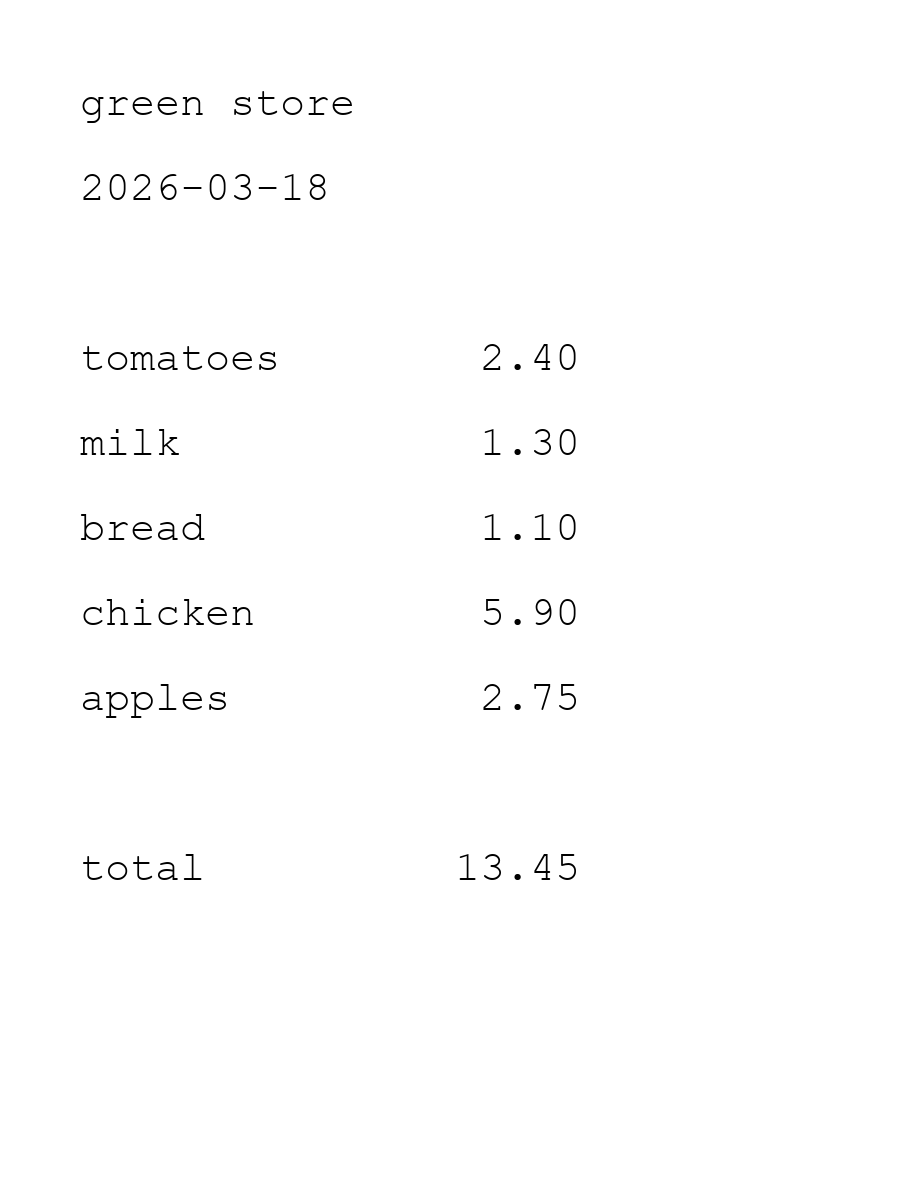

receipt items from OCR


,description,amount,category
0,tomatoes,2.40,Groceries
1,milk,1.30,Groceries
2,bread,1.10,Groceries
3,chicken,5.90,Groceries
4,apples,2.75,Groceries


added receipt rows: 5


In [35]:
receipt_items = pd.DataFrame()
receipt_path = None

if USE_RECEIPT_OCR:
    receipt_path = find_receipt_file(RECEIPT_FILE)

    if receipt_path is None:
        print('no receipt image was found')
    else:
        print('using receipt file:', receipt_path.name)
        display(NotebookImage(filename=str(receipt_path)))

        try:
            ocr_result = call_ocr_space(receipt_path, OCR_API_KEY, OCR_LANGUAGE)
            receipt_items = parse_receipt_items(ocr_result)

            if receipt_items.empty:
                print('OCR finished, but no receipt items were found')
            else:
                print('receipt items from OCR')
                display(receipt_items)
                add_receipt_items_to_manager(manager, receipt_items, RECEIPT_DATE)
                print('added receipt rows:', len(receipt_items))
        except Exception as error:
            print('receipt OCR was skipped:', error)
else:
    print('receipt OCR is turned off')

## Step 11. Final Tables And Statistics

Here we show the final table and the main results.

In [36]:
# apply budgets before analysis
manager.set_category_budgets(CATEGORY_BUDGETS)

# apply filters for analysis
analysis_df = manager.filter_transactions(
    category=FILTER_CATEGORY,
    start_date=FILTER_START_DATE,
    end_date=FILTER_END_DATE,
)

if analysis_df.empty:
    print('there are no transactions to analyze with current filters')
else:
    print('filtered transaction table')
    display(analysis_df.reset_index().rename(columns={'index': 'id'}))

    print('main statistics')
    display(pd.DataFrame([manager.main_stats(analysis_df)]))

    print('category breakdown')
    display(manager.category_breakdown(analysis_df))

    print('daily totals')
    display(manager.daily_trend(analysis_df))

    print('weekly summary')
    display(manager.weekly_summary(analysis_df))

    print('monthly summary')
    display(manager.monthly_summary(analysis_df))

    budget_df = manager.budget_report(analysis_df)
    if budget_df.empty:
        print('no category budgets were set')
    else:
        print('budget report')
        display(budget_df)

filtered transaction table


,id,date,amount,category,description
0,0,2026-02-20,420.00,Groceries,small supermarket run
1,1,2026-02-20,165.00,Transport,metro top up
2,2,2026-02-21,320.00,Cafe,coffee and cake
3,3,2026-02-21,890.00,Groceries,vegetables and chicken
4,4,2026-02-22,760.00,Entertainment,movie and popcorn
...,...,...,...,...,...
54,54,2026-03-20,1.10,Groceries,bread
55,55,2026-03-20,5.90,Groceries,chicken
56,56,2026-03-20,2.40,Groceries,tomatoes
57,57,2026-03-20,1.30,Groceries,milk


main statistics


,count,total_expense,average_expense,min_expense,max_expense
0,59,41158.45,697.6,1.1,3400.0


category breakdown


...

,week_start,amount
0,2026-02-16,2795.00
1,2026-02-23,10560.00
2,2026-03-02,12615.00
3,2026-03-09,11300.00
4,2026-03-16,3888.45


monthly summary


,month,amount
0,2026-02,11745.00
1,2026-03,29413.45


budget report


,category,budget,spent,remaining,status
0,Groceries,15000.0,11643.45,3356.55,Within budget
1,Shopping,5000.0,8650.00,-3650.00,Over budget
2,Cafe,2000.0,4550.00,-2550.00,Over budget
3,Entertainment,2000.0,3930.00,-1930.00,Over budget


## Step 12. Unified Charts Dashboard

This section combines category, budget, daily, weekly, monthly, and distribution charts into one structured dashboard.

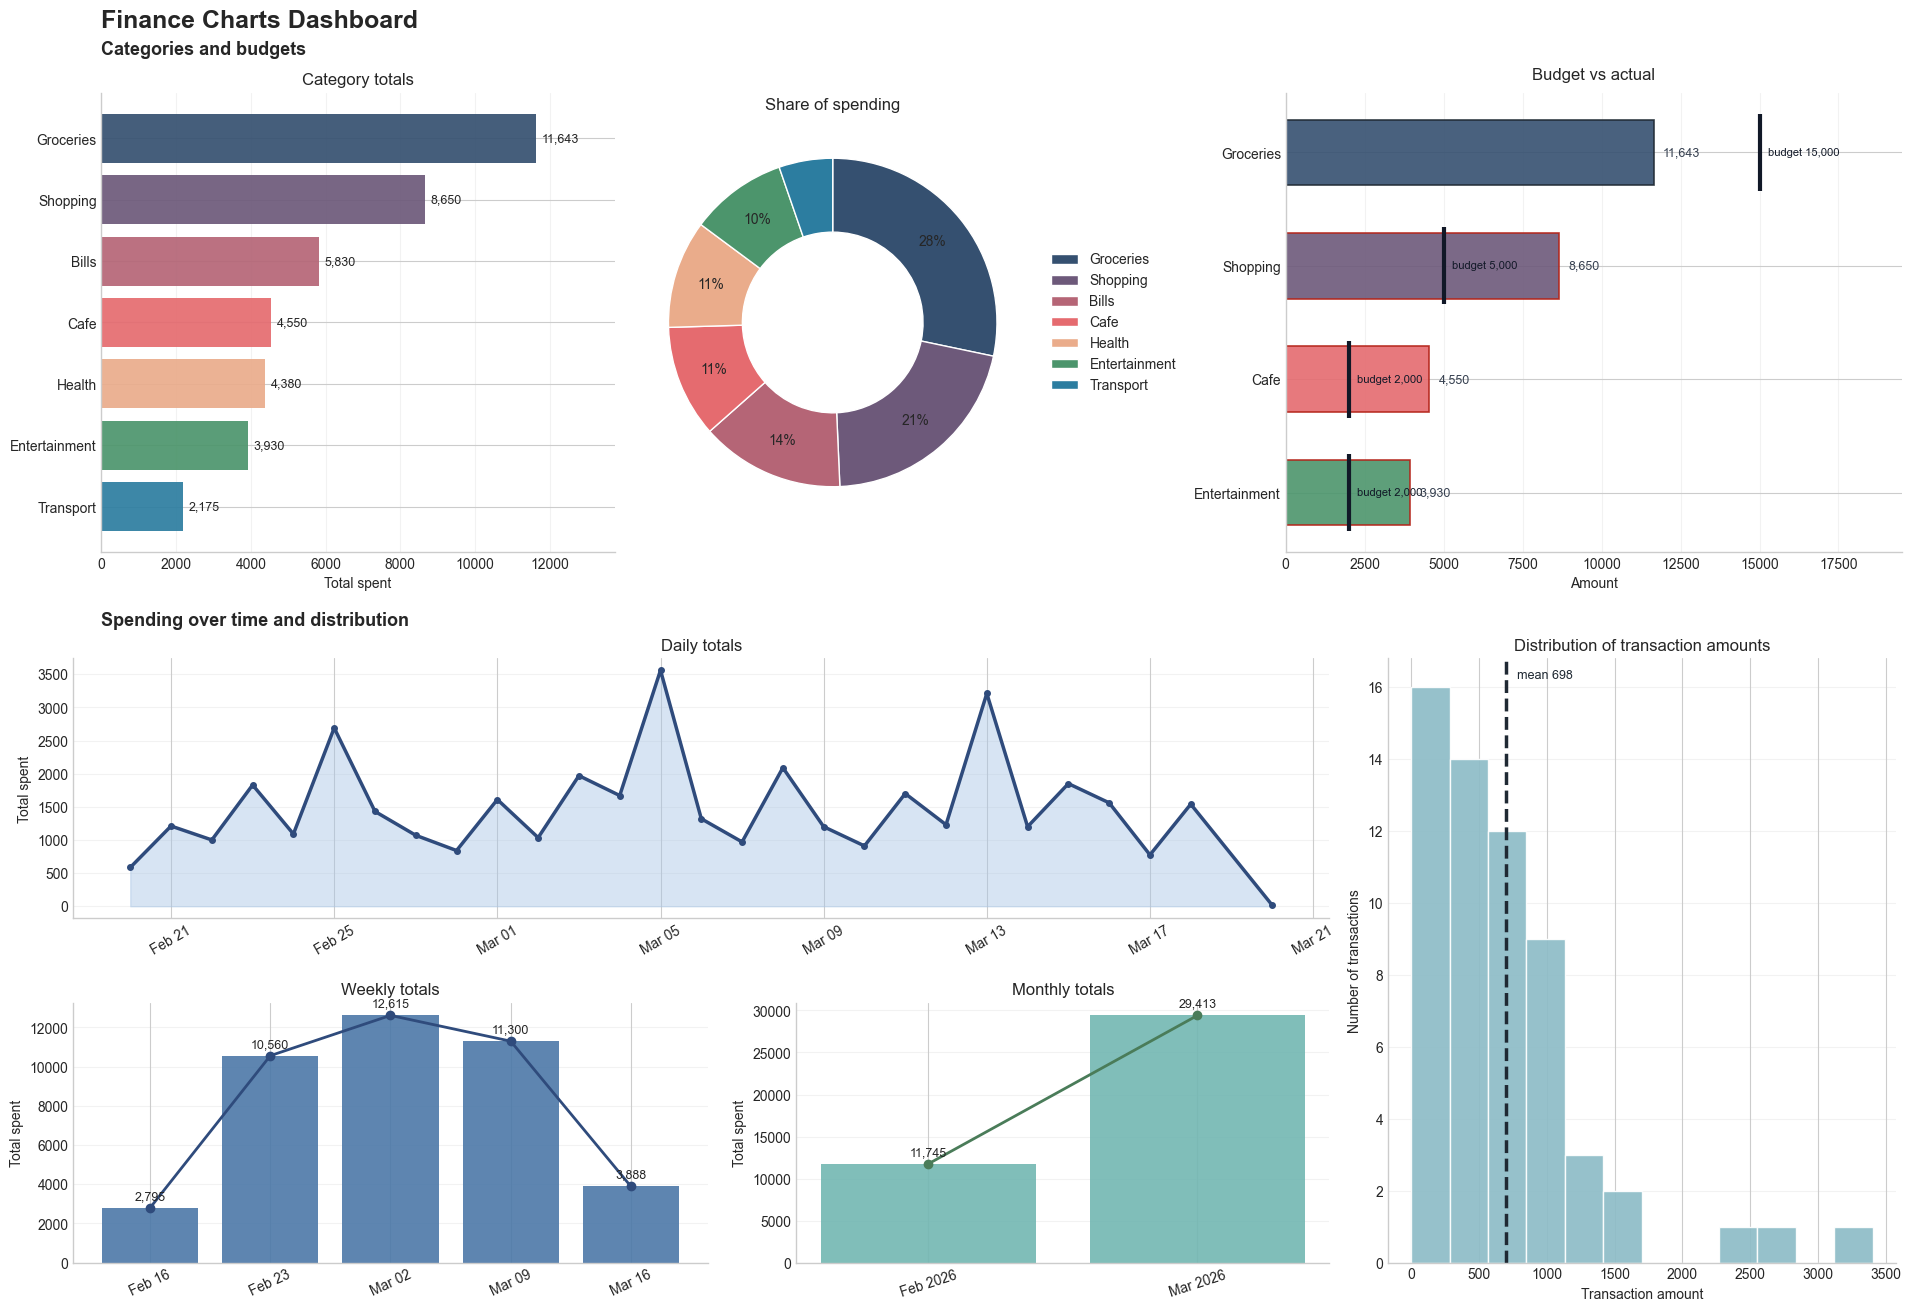

In [37]:
# rerun this cell after loading the data to refresh all charts in one dashboard
chart_df = manager.filter_transactions(
    category=FILTER_CATEGORY,
    start_date=FILTER_START_DATE,
    end_date=FILTER_END_DATE,
)

if chart_df.empty:
    print('no charts because there is no data')
else:
    category_df = manager.category_breakdown(chart_df).copy()
    daily_df = manager.daily_trend(chart_df).copy()
    weekly_df = manager.weekly_summary(chart_df).copy()
    monthly_df = manager.monthly_summary(chart_df).copy()
    budget_df = manager.budget_report(chart_df).copy()
    transaction_amounts = chart_df['amount'].astype(float)

    category_df = category_df.sort_values('amount', ascending=False).reset_index(drop=True)
    color_cycle = [
        '#355070',
        '#6D597A',
        '#B56576',
        '#E56B6F',
        '#EAAC8B',
        '#4C956C',
        '#2C7DA0',
    ]
    category_palette = {
        category: color_cycle[index % len(color_cycle)]
        for index, category in enumerate(category_df['category'])
    }

    fig = plt.figure(figsize=(19, 13), constrained_layout=True)
    fig.suptitle(
        'Finance Charts Dashboard',
        fontsize=18,
        fontweight='bold',
        x=0.05,
        ha='left',
    )

    category_fig, trend_fig = fig.subfigures(2, 1, height_ratios=[1.0, 1.25])
    category_fig.suptitle(
        'Categories and budgets',
        fontsize=13,
        fontweight='bold',
        x=0.05,
        ha='left',
    )
    trend_fig.suptitle(
        'Spending over time and distribution',
        fontsize=13,
        fontweight='bold',
        x=0.05,
        ha='left',
    )

    ax_totals, ax_share, ax_budget = category_fig.subplots(
        1,
        3,
        gridspec_kw={'width_ratios': [1.25, 1.0, 1.5]},
    )
    trend_axes = trend_fig.subplot_mosaic(
        [
            ['daily', 'daily', 'dist'],
            ['weekly', 'monthly', 'dist'],
        ],
        gridspec_kw={'width_ratios': [1.25, 1.05, 1.0]},
    )
    ax_daily = trend_axes['daily']
    ax_weekly = trend_axes['weekly']
    ax_monthly = trend_axes['monthly']
    ax_dist = trend_axes['dist']

    category_plot_df = category_df.copy()
    category_colors = [category_palette[category] for category in category_plot_df['category']]
    totals_bars = ax_totals.barh(
        category_plot_df['category'],
        category_plot_df['amount'],
        color=category_colors,
        alpha=0.92,
    )
    ax_totals.bar_label(
        totals_bars,
        labels=[f'{value:,.0f}' for value in category_plot_df['amount']],
        padding=4,
        fontsize=9,
    )
    ax_totals.set_title('Category totals')
    ax_totals.set_xlabel('Total spent')
    ax_totals.set_xlim(0, category_plot_df['amount'].max() * 1.18)
    ax_totals.grid(True, axis='x', alpha=0.25)
    ax_totals.invert_yaxis()

    share_wedges, _, _ = ax_share.pie(
        category_df['amount'],
        colors=[category_palette[category] for category in category_df['category']],
        startangle=90,
        counterclock=False,
        wedgeprops={'width': 0.45, 'edgecolor': 'white'},
        autopct=lambda pct: f'{pct:.0f}%' if pct >= 6 else '',
        pctdistance=0.78,
        textprops={'fontsize': 10},
    )
    ax_share.set_title('Share of spending')
    ax_share.legend(
        share_wedges,
        category_df['category'],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
    )

    if budget_df.empty:
        ax_budget.text(
            0.5,
            0.5,
            'No budgets set for the selected data.',
            ha='center',
            va='center',
            fontsize=11,
            transform=ax_budget.transAxes,
        )
        ax_budget.set_title('Budget vs actual')
        ax_budget.axis('off')
    else:
        rank_map = {category: index for index, category in enumerate(category_df['category'])}
        budget_plot_df = budget_df.copy()
        budget_plot_df['rank'] = budget_plot_df['category'].map(rank_map).fillna(len(rank_map))
        budget_plot_df = budget_plot_df.sort_values('rank').reset_index(drop=True)
        y_positions = np.arange(len(budget_plot_df))
        max_budget_value = budget_plot_df[['spent', 'budget']].to_numpy().max()

        for idx, row in budget_plot_df.iterrows():
            bar_color = category_palette.get(row['category'], '#355070')
            edge_color = '#B42318' if row['spent'] > row['budget'] else '#1F2933'
            ax_budget.barh(
                idx,
                row['spent'],
                color=bar_color,
                alpha=0.9,
                edgecolor=edge_color,
                linewidth=1.2,
                height=0.58,
                zorder=2,
            )
            ax_budget.vlines(
                row['budget'],
                idx - 0.34,
                idx + 0.34,
                color='#111827',
                linewidth=3,
                zorder=3,
            )
            ax_budget.text(
                row['spent'] + max_budget_value * 0.02,
                idx,
                f"{row['spent']:,.0f}",
                va='center',
                fontsize=9,
                color='#374151',
            )
            ax_budget.annotate(
                f"budget {row['budget']:,.0f}",
                xy=(row['budget'], idx),
                xytext=(6, 0),
                textcoords='offset points',
                ha='left',
                va='center',
                fontsize=8,
                color='#111827',
            )

        ax_budget.set_yticks(y_positions, budget_plot_df['category'])
        ax_budget.set_title('Budget vs actual', pad=10)
        ax_budget.set_xlabel('Amount')
        ax_budget.set_xlim(0, max_budget_value * 1.3)
        ax_budget.grid(True, axis='x', alpha=0.25)
        ax_budget.invert_yaxis()

    daily_df = daily_df.sort_values('date').reset_index(drop=True)
    ax_daily.plot(
        daily_df['date'],
        daily_df['amount'],
        color='#2F4B7C',
        linewidth=2.5,
        marker='o',
        markersize=4,
    )
    ax_daily.fill_between(
        daily_df['date'],
        daily_df['amount'],
        color='#A8C5E5',
        alpha=0.45,
    )
    ax_daily.set_title('Daily totals')
    ax_daily.set_ylabel('Total spent')
    ax_daily.grid(True, axis='y', alpha=0.25)
    ax_daily.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax_daily.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax_daily.tick_params(axis='x', rotation=30)

    weekly_df['label'] = weekly_df['week_start'].dt.strftime('%b %d')
    weekly_bars = ax_weekly.bar(
        weekly_df['label'],
        weekly_df['amount'],
        color='#4C78A8',
        alpha=0.9,
    )
    ax_weekly.plot(
        weekly_df['label'],
        weekly_df['amount'],
        color='#2F4B7C',
        linewidth=2,
        marker='o',
    )
    ax_weekly.bar_label(
        weekly_bars,
        labels=[f'{value:,.0f}' for value in weekly_df['amount']],
        padding=4,
        fontsize=9,
    )
    ax_weekly.set_title('Weekly totals')
    ax_weekly.set_ylabel('Total spent')
    ax_weekly.tick_params(axis='x', rotation=25)
    ax_weekly.grid(True, axis='y', alpha=0.25)

    monthly_df['label'] = pd.to_datetime(monthly_df['month'] + '-01').dt.strftime('%b %Y')
    monthly_bars = ax_monthly.bar(
        monthly_df['label'],
        monthly_df['amount'],
        color='#72B7B2',
        alpha=0.9,
    )
    ax_monthly.plot(
        monthly_df['label'],
        monthly_df['amount'],
        color='#4A7C59',
        linewidth=2,
        marker='o',
    )
    ax_monthly.bar_label(
        monthly_bars,
        labels=[f'{value:,.0f}' for value in monthly_df['amount']],
        padding=4,
        fontsize=9,
    )
    ax_monthly.set_title('Monthly totals')
    ax_monthly.set_ylabel('Total spent')
    ax_monthly.tick_params(axis='x', rotation=18)
    ax_monthly.grid(True, axis='y', alpha=0.25)

    hist_bins = max(1, min(12, len(transaction_amounts)))
    mean_transaction_amount = transaction_amounts.mean()
    ax_dist.hist(
        transaction_amounts,
        bins=hist_bins,
        color='#8DBCC7',
        alpha=0.92,
        edgecolor='white',
    )
    ax_dist.axvline(
        mean_transaction_amount,
        color='#1F2933',
        linewidth=2.5,
        linestyle='--',
    )
    ax_dist.annotate(
        f"mean {mean_transaction_amount:,.0f}",
        xy=(mean_transaction_amount, 1),
        xycoords=('data', 'axes fraction'),
        xytext=(8, -8),
        textcoords='offset points',
        ha='left',
        va='top',
        fontsize=9,
        color='#1F2933',
    )
    ax_dist.set_title('Distribution of transaction amounts')
    ax_dist.set_xlabel('Transaction amount')
    ax_dist.set_ylabel('Number of transactions')
    ax_dist.grid(True, axis='y', alpha=0.25)

    for ax in (ax_totals, ax_budget, ax_daily, ax_weekly, ax_monthly, ax_dist):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.show()


## Step 13. Simple Budget Forecast

This forecast uses a very simple pace model: it takes the current month spending so far, divides by the elapsed days, and projects the full month from that pace.

simple forecast for March 2026 (using data through 2026-03-20)
spent so far this month: 29,413.45 | projected month-end total: 45,590.85
days observed: 20 of 31 | remaining days: 11
categories likely to exceed the budget at the current pace
- Shopping: projected 9,532.50 vs budget 5,000.00 (4,532.50 over)
- Cafe: projected 5,208.00 vs budget 2,000.00 (3,208.00 over)
- Entertainment: projected 4,371.00 vs budget 2,000.00 (2,371.00 over)


,category,spent_so_far,budget,projected_total,projected_gap,safe_daily_limit,status
0,Shopping,6150.00,5000.0,9532.50,4532.50,0.00,Likely over budget
1,Cafe,3360.00,2000.0,5208.00,3208.00,0.00,Likely over budget
2,Entertainment,2820.00,2000.0,4371.00,2371.00,0.00,Likely over budget
3,Groceries,8213.45,15000.0,12730.85,-2269.15,616.96,On track


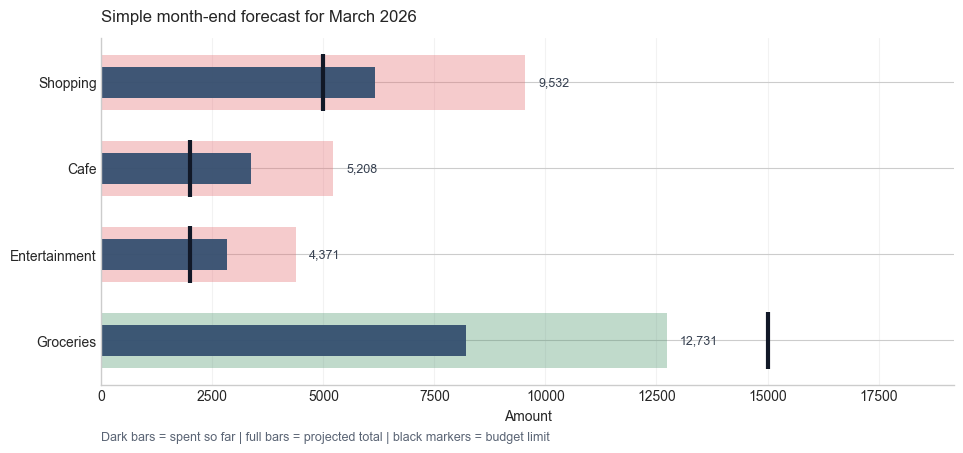

In [38]:
# simple month-end forecast based on the current month spending pace
manager.set_category_budgets(CATEGORY_BUDGETS)

forecast_source_df = manager.filter_transactions(
    category=FILTER_CATEGORY,
    start_date=FILTER_START_DATE,
    end_date=FILTER_END_DATE,
)

if forecast_source_df.empty:
    print('no forecast because there is no data')
elif not getattr(manager, 'category_budgets', {}):
    print('no forecast because no category budgets are set')
else:
    forecast_source_df = forecast_source_df.copy()
    forecast_source_df['date'] = pd.to_datetime(forecast_source_df['date'])

    latest_date = forecast_source_df['date'].max()
    latest_period = latest_date.to_period('M')
    current_month_df = forecast_source_df[
        forecast_source_df['date'].dt.to_period('M') == latest_period
    ].copy()

    if current_month_df.empty:
        print('no forecast because there is no data for the latest month in the selection')
    else:
        days_elapsed = int(latest_date.day)
        days_in_month = int(latest_date.days_in_month)
        remaining_days = max(days_in_month - days_elapsed, 0)

        month_label = latest_date.strftime('%B %Y')
        category_spend = (
            current_month_df.groupby('category', as_index=False)['amount']
            .sum()
            .rename(columns={'amount': 'spent_so_far'})
        )

        forecast_rows = []
        for category, budget in manager.category_budgets.items():
            matched_spend = category_spend.loc[
                category_spend['category'] == category,
                'spent_so_far',
            ]
            spent_so_far = float(matched_spend.iloc[0]) if not matched_spend.empty else 0.0
            pace_per_day = spent_so_far / max(days_elapsed, 1)
            projected_total = round(pace_per_day * days_in_month, 2)
            projected_gap = round(projected_total - budget, 2)
            projected_extra = round(max(projected_total - spent_so_far, 0), 2)

            if projected_gap > 0:
                status = 'Likely over budget'
            elif projected_gap < 0:
                status = 'On track'
            else:
                status = 'Right on budget'

            safe_daily_limit = None
            if remaining_days > 0:
                safe_daily_limit = round(max(budget - spent_so_far, 0) / remaining_days, 2)

            forecast_rows.append(
                {
                    'category': category,
                    'spent_so_far': round(spent_so_far, 2),
                    'budget': round(float(budget), 2),
                    'projected_total': projected_total,
                    'projected_extra': projected_extra,
                    'projected_gap': projected_gap,
                    'safe_daily_limit': safe_daily_limit,
                    'status': status,
                }
            )

        forecast_df = pd.DataFrame(forecast_rows)
        forecast_df = forecast_df.sort_values(
            ['projected_gap', 'projected_total'],
            ascending=[False, False],
        ).reset_index(drop=True)

        total_spent_so_far = round(float(current_month_df['amount'].sum()), 2)
        total_projected = round(total_spent_so_far / max(days_elapsed, 1) * days_in_month, 2)

        print(
            f'simple forecast for {month_label} '
            f'(using data through {latest_date.strftime("%Y-%m-%d")})'
        )
        print(
            f'spent so far this month: {total_spent_so_far:,.2f} | '
            f'projected month-end total: {total_projected:,.2f}'
        )
        print(
            f'days observed: {days_elapsed} of {days_in_month} | '
            f'remaining days: {remaining_days}'
        )

        over_budget_df = forecast_df[forecast_df['projected_gap'] > 0].copy()
        if over_budget_df.empty:
            print('at the current pace, all budgeted categories are on track')
        else:
            print('categories likely to exceed the budget at the current pace')
            for _, row in over_budget_df.iterrows():
                print(
                    f"- {row['category']}: projected {row['projected_total']:,.2f} vs "
                    f"budget {row['budget']:,.2f} "
                    f"({row['projected_gap']:,.2f} over)"
                )

        display(
            forecast_df[
                [
                    'category',
                    'spent_so_far',
                    'budget',
                    'projected_total',
                    'projected_gap',
                    'safe_daily_limit',
                    'status',
                ]
            ]
        )

        plot_df = forecast_df.sort_values(
            ['projected_gap', 'projected_total'],
            ascending=[False, False],
        ).reset_index(drop=True)
        y_positions = np.arange(len(plot_df))
        max_value = max(plot_df[['spent_so_far', 'budget', 'projected_total']].to_numpy().max(), 1)
        projection_colors = [
            '#E56B6F' if value > 0 else '#4C956C'
            for value in plot_df['projected_gap']
        ]

        fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_df) * 0.8)))
        ax.barh(
            y_positions,
            plot_df['projected_total'],
            color=projection_colors,
            alpha=0.35,
            height=0.64,
            zorder=1,
        )
        ax.barh(
            y_positions,
            plot_df['spent_so_far'],
            color='#355070',
            alpha=0.95,
            height=0.36,
            zorder=2,
        )

        for idx, row in plot_df.iterrows():
            ax.vlines(
                row['budget'],
                idx - 0.33,
                idx + 0.33,
                color='#111827',
                linewidth=3,
                zorder=3,
            )
            ax.text(
                row['projected_total'] + max_value * 0.02,
                idx,
                f"{row['projected_total']:,.0f}",
                va='center',
                fontsize=9,
                color='#374151',
            )

        ax.set_yticks(y_positions, plot_df['category'])
        ax.set_title(
            f'Simple month-end forecast for {month_label}',
            loc='left',
            pad=12,
        )
        ax.text(
            0.0,
            -0.16,
            'Dark bars = spent so far | full bars = projected total | black markers = budget limit',
            transform=ax.transAxes,
            fontsize=9,
            color='#5B6575',
        )
        ax.set_xlabel('Amount')
        ax.set_xlim(0, max_value * 1.28)
        ax.grid(True, axis='x', alpha=0.25)
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()